# Clone archetypes: recovering tumor sub-clones with the simple-archetypes method

This notebook studies whether the **simple-archetypes** soft-labeling method can
(i) discriminate **tumor** reads from **healthy** reads and (ii) recover the
**sub-clones** (subtypes) of the tumor cell type in an unsupervised way.

We play the following roles with Loyfer cell types:

- a **healthy** cell type (`HEALTHY_CTYPE`), and
- a **tumor** cell type (`TUMOR_CTYPE`), whose **clones** (`TUMOR_CLONES`) are the
  refined sub-types of that cell type.

The notebook is organized in four parts:

1. **Data preparation** — configuration, DMR selection and read extraction.
2. **Noisy samples** — how to build mixtures of the healthy and tumor reads.
3. **Experiment 1** — fit the simple-archetypes method on noisy (healthy+tumor)
   samples, retrieve the archetypes, score every read and evaluate the
   healthy-vs-tumor classification (precision-recall, auPRC, ...).
4. **Experiment 2** — build samples with varying **clone** proportions, run the
   method with a user-defined number of archetypes and a random proportion init,
   score the longest reads and visualize (clustered heatmap with a true-origin
   track) whether the archetypes recovered the clones.


## Part 1 — Data preparation

In [ ]:
import os
import sys
from pathlib import Path
import math


# utils.py loads ./data/files_to_cell_groups.json relative to the working
# directory, and the reference notebook uses paths relative to
# `extract_soft_labels_from_noisy_samples`. We therefore move the working
# directory to that parent folder (idempotent) and make it importable.
_cwd = Path.cwd()
if _cwd.name == "clone_archetypes":
    os.chdir(_cwd.parent)
BASE_DIR = Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))
print("Working directory:", BASE_DIR)

Working directory: /vsc-hard-mounts/leuven-data/389/vsc38912/Projects/syto/EDA/extract_soft_labels_from_noisy_samples


In [175]:
from collections import defaultdict
from typing import Dict, List

import json
import numpy as np
import pandas as pd
import pysam
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec

from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score,
)

from utils import (
    filename2ctype,
    compute_counts_sig_per_ctype_from_dataset,
    extract_complete_dataset,
    compute_num_reads_in_dataset,
    generate_bootstrap_sample_from_dataset,
    get_sig_from_idx,
)
from methods import (
    naive_sl_without_pooling,
    sl_with_simple_archetypes_with_multiple_regions,
)

%load_ext autoreload
%autoreload 2

EPS = 1e-10

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Configuration

In [3]:
# --- Cell-type roles -------------------------------------------------------
HEALTHY_CTYPE = "Liver-Hep"  # Loyfer cell type playing the healthy cell
TUMOR_CTYPE = "Pancreas"  # label of the tumor cell (may be a synthetic aggregate)

# Whether the tumor CLONES are themselves real atlas cell types (like the
# Pancreas sub-types), as opposed to refined sub-types of an atlas cell type
# (like the Blood-T refinement). This governs how the clones are read and how the
# tumor-specific DMRs are selected.
#   - True  (Pancreas case): each clone is a real Loyfer cell type, on the same
#     level as HEALTHY_CTYPE. "Pancreas" itself is NOT in the atlas; it is only a
#     synthetic aggregate key used to group the clones together.
#   - False (Blood-T case): TUMOR_CTYPE is a real atlas cell type and the clones
#     are its refined sub-types (read from the refined file->group mapping).
TUMOR_CLONES_ARE_ATLAS_CTYPES = True

if TUMOR_CLONES_ARE_ATLAS_CTYPES:
    TUMOR_CLONES = [
        "Pancreas-Alpha",
        "Pancreas-Beta",
        "Pancreas-Delta",
        "Pancreas-Acinar",
        "Pancreas-Duct",
    ]
    _refined_map = None
else:
    # The tumor "clones" are the refined sub-types of TUMOR_CTYPE, read from the
    # refined file->group mapping (all groups that are sub-types of TUMOR_CTYPE).
    _refined_map = json.load(
        open("./data/files_to_cell_groups_blood_t_refined.json", "r", encoding="utf-8")
    )
    TUMOR_CLONES = sorted(
        {v for v in _refined_map.values() if v.startswith(TUMOR_CTYPE + "-")}
    )

# --- Region (DMR) selection ------------------------------------------------
# Number of DMRs *specific to* HEALTHY_CTYPE and (separately) *specific to* each
# tumor target. When the clones are atlas cell types, the tumor-specific DMRs are
# selected PER CLONE (N_SPECIFIC_REGIONS for each clone); otherwise they are the
# N_SPECIFIC_REGIONS DMRs specific to TUMOR_CTYPE.
N_SPECIFIC_REGIONS = 2
# Number of DMRs specific to *neither* HEALTHY_CTYPE nor any tumor target.
N_UNSPECIFIC_REGIONS = 6

# --- Signature caps (keep archetype size / runtime manageable) -------------
LIMIT_NUMBER_START_POSITIONS_PER_REGION = 10
MAX_SIGNATURE_READ_LENGTH = 8

# --- Reproducibility -------------------------------------------------------
RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

# The two cell types used by the archetype model (order fixes the column order
# of P(sig | ctype): 0 -> healthy, 1 -> tumor).
SELECTED_CTYPES = [HEALTHY_CTYPE, TUMOR_CTYPE]
N_CTYPES = len(SELECTED_CTYPES)
HEALTHY_IDX, TUMOR_IDX = 0, 1

print(f"Healthy cell type: {HEALTHY_CTYPE}")
print(f"Tumor cell type:   {TUMOR_CTYPE}")
print(f"Tumor clones ({len(TUMOR_CLONES)}): {TUMOR_CLONES}")

Healthy cell type: Liver-Hep
Tumor cell type:   Pancreas
Tumor clones (5): ['Pancreas-Alpha', 'Pancreas-Beta', 'Pancreas-Delta', 'Pancreas-Acinar', 'Pancreas-Duct']


In [4]:
def filename2clone(f_name: str):
    """Map a .pat.gz filename to its tumor-clone label (or None)."""
    if TUMOR_CLONES_ARE_ATLAS_CTYPES:
        # The clones are real atlas cell types -> the standard mapping already
        # returns the clone label directly.
        clone = filename2ctype(f_name)
        return clone if clone in TUMOR_CLONES else None
    f_name = os.path.basename(f_name)
    f_name_short = "_".join(f_name.split("_")[1:]).split(".hg38")[0]
    return _refined_map.get(f_name_short)

### Loading the coverage, atlas and labels

In [5]:
df_coverage_per_ctype_per_dmr = pd.read_csv(Path("./data/region_coverage.csv"))
df_coverage_per_ctype_per_dmr.columns = [
    col if col != "Ovary+Endom-Ep" else "Ovary-Ep"
    for col in df_coverage_per_ctype_per_dmr.columns
]
atlas = pd.read_csv(Path("../../Data/Atlas.U25.l4.hg38.full.tsv"), sep="\t")
map_region_key_to_target = atlas.set_index(["chr", "start", "end"])["target"].to_dict()
df_coverage_per_ctype_per_dmr["target"] = df_coverage_per_ctype_per_dmr.apply(
    lambda row: map_region_key_to_target.get((row["chr"], row["start"], row["end"])),
    axis=1,
)

labels_dict = json.load(open(Path("../../App/labels_dict.json"), "r", encoding="utf-8"))
labels_dict = {int(k): v for k, v in labels_dict.items()}
labels_list = [labels_dict[i] for i in range(len(labels_dict))]

assert HEALTHY_CTYPE in labels_list, f"{HEALTHY_CTYPE} not in the atlas labels"
if TUMOR_CLONES_ARE_ATLAS_CTYPES:
    # TUMOR_CTYPE is a synthetic aggregate that need NOT be in the atlas, but each
    # clone must be a real atlas cell type.
    missing_clones = [c for c in TUMOR_CLONES if c not in labels_list]
    assert not missing_clones, f"Tumor clones not in the atlas labels: {missing_clones}"
else:
    assert TUMOR_CTYPE in labels_list, f"{TUMOR_CTYPE} not in the atlas labels"

### Selecting the DMRs

We keep the archetype cell types **fixed** to `HEALTHY_CTYPE` and `TUMOR_CTYPE`, and
select:

- `N_SPECIFIC_REGIONS` DMRs whose target is `HEALTHY_CTYPE`,
- tumor-specific DMRs: `N_SPECIFIC_REGIONS` DMRs **per tumor target**. When the
  clones are atlas cell types (`TUMOR_CLONES_ARE_ATLAS_CTYPES`), each clone is a
  real target, so this yields `N_SPECIFIC_REGIONS` DMRs for **every** clone;
  otherwise it is `N_SPECIFIC_REGIONS` DMRs specific to `TUMOR_CTYPE`,
- `N_UNSPECIFIC_REGIONS` DMRs whose target is **neither** `HEALTHY_CTYPE` nor any
  tumor target,

taking, within each group, the DMRs with the **highest worst-case coverage**. The
tumor coverage of a region is the **worst-case (min) coverage over all clones**
when the clones are atlas cell types (so a region is only picked if every clone is
well covered there), and simply the `TUMOR_CTYPE` coverage otherwise.


In [6]:
df_valid_regions = df_coverage_per_ctype_per_dmr[
    df_coverage_per_ctype_per_dmr["target"].isin(labels_list)
].reset_index(drop=True)

cov_healthy = df_valid_regions[HEALTHY_CTYPE].values.astype(float)
if TUMOR_CLONES_ARE_ATLAS_CTYPES:
    # A tumor-specific region is only useful if EVERY clone is well covered there,
    # so rank by the worst-case (min) coverage over all clones.
    cov_tumor = df_valid_regions[TUMOR_CLONES].values.astype(float).min(axis=1)
    tumor_targets = set(TUMOR_CLONES)
else:
    cov_tumor = df_valid_regions[TUMOR_CTYPE].values.astype(float)
    tumor_targets = {TUMOR_CTYPE}
min_coverage_per_region = np.minimum(cov_healthy, cov_tumor)
target_per_region = df_valid_regions["target"].values


def top_rows_by_coverage(rows, n):
    rows = rows[np.argsort(min_coverage_per_region[rows])[::-1]]
    assert len(rows) >= n, f"Only {len(rows)} DMRs available, {n} requested."
    return rows[:n]


healthy_rows = top_rows_by_coverage(
    np.where(target_per_region == HEALTHY_CTYPE)[0], N_SPECIFIC_REGIONS
)

# Tumor-specific DMRs: N_SPECIFIC_REGIONS per tumor target. When the clones are
# atlas cell types this yields N_SPECIFIC_REGIONS DMRs for EACH clone; otherwise
# it is simply N_SPECIFIC_REGIONS DMRs specific to TUMOR_CTYPE.
tumor_rows = []
for tumor_target in sorted(tumor_targets):
    tumor_rows.extend(
        top_rows_by_coverage(
            np.where(target_per_region == tumor_target)[0], N_SPECIFIC_REGIONS
        )
    )
tumor_rows = np.array(tumor_rows, dtype=int)

excluded_targets = {HEALTHY_CTYPE} | tumor_targets
unspecific_rows = np.where(~np.isin(target_per_region, list(excluded_targets)))[0]
unspecific_rows = top_rows_by_coverage(unspecific_rows, N_UNSPECIFIC_REGIONS)

selected_region_rows = list(healthy_rows) + list(tumor_rows) + list(unspecific_rows)

selected_regions = []
for region_id, row_idx in enumerate(selected_region_rows):
    row = df_valid_regions.iloc[int(row_idx)]
    if row["target"] == HEALTHY_CTYPE:
        setting = "healthy_specific"
    elif row["target"] in tumor_targets:
        setting = "tumor_specific"
    else:
        setting = "unspecific"
    selected_regions.append(
        {
            "region_id": region_id,
            "chr": row["chr"],
            "start": int(row["start"]),
            "end": int(row["end"]),
            "startCpG": int(row["startCpG"]),
            "endCpG": int(row["endCpG"]),
            "fetch_start": int(row["startCpG"]) - 50,
            "target": row["target"],
            "setting": setting,
        }
    )

N_REGIONS = len(selected_regions)
pd.DataFrame(selected_regions)[
    ["region_id", "setting", "chr", "startCpG", "endCpG", "target"]
]

,region_id,setting,chr,startCpG,endCpG,target
0,0,healthy_specific,chr14,20096295,20096310,Liver-Hep
1,1,healthy_specific,chr20,26336340,26336349,Liver-Hep
2,2,tumor_specific,chr11,17582874,17582891,Pancreas-Acinar
3,3,tumor_specific,chr16,22525977,22526004,Pancreas-Acinar
4,4,tumor_specific,chr5,8386618,8386628,Pancreas-Alpha
5,5,tumor_specific,chr4,7387348,7387354,Pancreas-Alpha
6,6,tumor_specific,chr7,11971498,11971511,Pancreas-Beta
7,7,tumor_specific,chr17,23404144,23404158,Pancreas-Beta
8,8,tumor_specific,chr10,16305815,16305825,Pancreas-Delta
9,9,tumor_specific,chr4,6375871,6375878,Pancreas-Delta


### Extraction of reads



For each selected region we extract reads from:

- the **healthy** files (`filename2ctype(...) == HEALTHY_CTYPE`), stored under the
  source key `HEALTHY_CTYPE`, and
- the **tumor clone** files (`filename2clone(...) in TUMOR_CLONES`), stored under
  the source key equal to the clone label,

so we can keep track of the clone each tumor read comes from. The raw reads are
organized as ``raw_reads_dataset[region_id][source][read_length][start][pattern]``.


In [7]:
PATH_TO_DATA = Path(
    "/staging/leuven/stg_00118/methylDL/data/loyfer2023/hg38/data/GSE186458"
)

files_per_source = defaultdict(list)
for file in PATH_TO_DATA.glob("*.pat.gz"):
    if filename2ctype(file.name) == HEALTHY_CTYPE:
        files_per_source[HEALTHY_CTYPE].append(file)
        continue
    clone = filename2clone(file.name)
    if clone in TUMOR_CLONES:
        files_per_source[clone].append(file)
files_per_source = dict(files_per_source)

SOURCES = [HEALTHY_CTYPE] + [c for c in TUMOR_CLONES if c in files_per_source]
print("Number of files per source:")
{source: len(files_per_source.get(source, [])) for source in SOURCES}

Number of files per source:


{'Liver-Hep': 6,
 'Pancreas-Alpha': 3,
 'Pancreas-Beta': 3,
 'Pancreas-Delta': 3,
 'Pancreas-Acinar': 4,
 'Pancreas-Duct': 4}

In [8]:
raw_reads_dataset = {
    region["region_id"]: defaultdict(
        lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    )
    for region in selected_regions
}

n_loops = sum(len(files) for files in files_per_source.values())
with tqdm(total=n_loops, desc="Extracting reads") as pbar:
    for source, files in files_per_source.items():
        for file in files:
            csi_file_path = str(file) + ".csi"
            tbx = pysam.TabixFile(str(file), index=csi_file_path)
            for region in selected_regions:
                region_id = region["region_id"]
                dmr_start_cpg = region["startCpG"]
                dmr_end_cpg = region["endCpG"]
                for row in tbx.fetch(
                    region["chr"], region["fetch_start"], dmr_end_cpg + 1
                ):
                    parts = row.split("\t")
                    read_start = int(parts[1])
                    pattern = parts[2]
                    n_reads = int(parts[3])
                    read_end = read_start + len(pattern)  # exclusive
                    if read_end < dmr_start_cpg:
                        continue
                    if read_start >= dmr_end_cpg:
                        continue
                    cropped_start = max(read_start, dmr_start_cpg)
                    cropped_end = min(read_end, dmr_end_cpg)
                    cropped_pattern = pattern[
                        cropped_start - read_start : cropped_end - read_start
                    ]
                    if len(cropped_pattern) == 0:
                        continue
                    cropped_pattern = cropped_pattern.replace("C", "1").replace(
                        "T", "0"
                    )
                    raw_reads_dataset[region_id][source][len(cropped_pattern)][
                        cropped_start
                    ][cropped_pattern] += n_reads
            pbar.update(1)

for region in selected_regions:
    region_id = region["region_id"]
    n_reads = compute_num_reads_in_dataset(raw_reads_dataset[region_id])
    print(
        f"Region {region_id} ({region['setting']}, target={region['target']}): "
        f"{n_reads} raw reads"
    )

Extracting reads:   0%|          | 0/23 [00:00<?, ?it/s]

Extracting reads: 100%|██████████| 23/23 [00:11<00:00,  2.02it/s]

Region 0 (healthy_specific, target=Liver-Hep): 4620 raw reads
Region 1 (healthy_specific, target=Liver-Hep): 4232 raw reads
Region 2 (tumor_specific, target=Pancreas-Acinar): 5843 raw reads
Region 3 (tumor_specific, target=Pancreas-Acinar): 4914 raw reads
Region 4 (tumor_specific, target=Pancreas-Alpha): 4327 raw reads
Region 5 (tumor_specific, target=Pancreas-Alpha): 3787 raw reads
Region 6 (tumor_specific, target=Pancreas-Beta): 3238 raw reads
Region 7 (tumor_specific, target=Pancreas-Beta): 2475 raw reads
Region 8 (tumor_specific, target=Pancreas-Delta): 4147 raw reads
Region 9 (tumor_specific, target=Pancreas-Delta): 4230 raw reads
Region 10 (tumor_specific, target=Pancreas-Duct): 6122 raw reads
Region 11 (tumor_specific, target=Pancreas-Duct): 5153 raw reads
Region 12 (unspecific, target=Gallbladder): 7049 raw reads
Region 13 (unspecific, target=Blood-T): 6086 raw reads
Region 14 (unspecific, target=Thyroid-Ep): 5363 raw reads
Region 15 (unspecific, target=Lung-Ep-Alveo): 5455 raw

In [9]:
# Optionally cap the number of signature start positions per region.
if LIMIT_NUMBER_START_POSITIONS_PER_REGION is not None:
    for region in selected_regions:
        region_id = region["region_id"]
        all_start_positions = set()
        for source, length_dict in raw_reads_dataset[region_id].items():
            for length, start_dict in length_dict.items():
                all_start_positions.update(start_dict.keys())
        authorized = set(
            sorted(all_start_positions)[:LIMIT_NUMBER_START_POSITIONS_PER_REGION]
        )
        for source, length_dict in raw_reads_dataset[region_id].items():
            for length, start_dict in length_dict.items():
                for start in list(start_dict.keys()):
                    if start not in authorized:
                        del start_dict[start]

We split the raw reads at the unknown positions `.` to obtain, per source, the
`og` (original) reads. We then build two views:

- a **clone-level** view `og_dataset_per_source` (one key per source), used later
  to build clone mixtures and to keep the true origin of each read, and
- a **ctype-level** view `og_dataset` with only `HEALTHY_CTYPE` and `TUMOR_CTYPE`
  (all clones merged into `TUMOR_CTYPE`), used to define the signatures and to fit
  the 2-cell-type archetype model.


In [10]:
def split_reads_at_unknown(source_length_dict):
    """Split patterns at '.' for a single source ({L: {start: {pattern: count}}})."""
    out = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    for read_length in sorted(source_length_dict.keys()):
        for start, pattern_counts in source_length_dict[read_length].items():
            for pattern, n_reads in pattern_counts.items():
                current_pos = start
                for subpattern in pattern.split("."):
                    subpattern_start = current_pos
                    current_pos += len(subpattern)
                    if len(subpattern) == 0:
                        continue
                    out[len(subpattern)][subpattern_start][subpattern] += n_reads
    return out


def merge_source_datasets(list_of_ds):
    """Merge several {L: {start: {pattern: count}}} dicts into one."""
    merged = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    for ds in list_of_ds:
        for read_length, start_dict in ds.items():
            for start, pattern_counts in start_dict.items():
                for pattern, n_reads in pattern_counts.items():
                    merged[read_length][start][pattern] += n_reads
    return merged


og_dataset_per_source = {}  # [region_id][source] -> {L: {start: {pattern: count}}}
og_dataset = {}  # [region_id][ctype]  -> {L: {start: {pattern: count}}}
for region in selected_regions:
    region_id = region["region_id"]
    per_source = {
        source: split_reads_at_unknown(length_dict)
        for source, length_dict in raw_reads_dataset[region_id].items()
    }
    og_dataset_per_source[region_id] = per_source

    healthy_ds = per_source.get(HEALTHY_CTYPE, defaultdict(dict))
    tumor_ds = merge_source_datasets(
        [per_source[c] for c in TUMOR_CLONES if c in per_source]
    )
    og_dataset[region_id] = {HEALTHY_CTYPE: healthy_ds, TUMOR_CTYPE: tumor_ds}

for region in selected_regions:
    region_id = region["region_id"]
    n_h = compute_num_reads_in_dataset(
        {HEALTHY_CTYPE: og_dataset[region_id][HEALTHY_CTYPE]}
    )
    n_t = compute_num_reads_in_dataset(
        {TUMOR_CTYPE: og_dataset[region_id][TUMOR_CTYPE]}
    )
    print(
        f"Region {region_id}: {n_h} healthy reads, {n_t} tumor reads (after splitting)"
    )

Region 0: 998 healthy reads, 2114 tumor reads (after splitting)
Region 1: 1335 healthy reads, 2954 tumor reads (after splitting)
Region 2: 1474 healthy reads, 3533 tumor reads (after splitting)
Region 3: 642 healthy reads, 1546 tumor reads (after splitting)
Region 4: 1345 healthy reads, 3063 tumor reads (after splitting)
Region 5: 1140 healthy reads, 2666 tumor reads (after splitting)
Region 6: 783 healthy reads, 1881 tumor reads (after splitting)
Region 7: 587 healthy reads, 1463 tumor reads (after splitting)
Region 8: 1324 healthy reads, 2844 tumor reads (after splitting)
Region 9: 1259 healthy reads, 3001 tumor reads (after splitting)
Region 10: 1769 healthy reads, 4375 tumor reads (after splitting)
Region 11: 711 healthy reads, 1866 tumor reads (after splitting)
Region 12: 1028 healthy reads, 2211 tumor reads (after splitting)
Region 13: 1757 healthy reads, 4040 tumor reads (after splitting)
Region 14: 1091 healthy reads, 2410 tumor reads (after splitting)
Region 15: 1613 healthy r

We build the ctype-level **complete** dataset (each read of size $n$ also
contributes all of its sub-reads) and derive, per region, the `(start,
read_length)` **signature positions** common to the healthy and tumor cell types.


In [11]:
complete_og_dataset = {
    region["region_id"]: extract_complete_dataset(og_dataset[region["region_id"]])
    for region in selected_regions
}

signature_positions = {}
for region in selected_regions:
    region_id = region["region_id"]

    start_positions_per_ctype = defaultdict(set)
    for ctype, length_dict in complete_og_dataset[region_id].items():
        for read_length, start_dict in length_dict.items():
            for start in start_dict.keys():
                start_positions_per_ctype[ctype].add(start)
    common_start_positions = set.intersection(*start_positions_per_ctype.values())

    sig_pos_per_ctype = defaultdict(lambda: defaultdict(set))
    for ctype, length_dict in complete_og_dataset[region_id].items():
        for read_length, start_dict in length_dict.items():
            if read_length > MAX_SIGNATURE_READ_LENGTH:
                continue
            for start in start_dict.keys():
                if start not in common_start_positions:
                    continue
                sig_pos_per_ctype[ctype][start].add(read_length)

    region_sig_positions = {}
    for start in common_start_positions:
        common_read_lengths = set.intersection(
            *[sig_pos_per_ctype[ctype][start] for ctype in SELECTED_CTYPES]
        )
        if len(common_read_lengths) > 0:
            region_sig_positions[start] = common_read_lengths
    signature_positions[region_id] = region_sig_positions

    assert (
        len(region_sig_positions) > 0
    ), f"Region {region_id} has no common signatures."
    n_sigs = sum(len(v) for v in region_sig_positions.values())
    print(f"Region {region_id}: {n_sigs} (start, read_length) signature positions")

Region 0: 69 (start, read_length) signature positions
Region 1: 32 (start, read_length) signature positions
Region 2: 81 (start, read_length) signature positions
Region 3: 132 (start, read_length) signature positions
Region 4: 46 (start, read_length) signature positions
Region 5: 15 (start, read_length) signature positions
Region 6: 76 (start, read_length) signature positions
Region 7: 84 (start, read_length) signature positions
Region 8: 33 (start, read_length) signature positions
Region 9: 17 (start, read_length) signature positions
Region 10: 21 (start, read_length) signature positions
Region 11: 74 (start, read_length) signature positions
Region 12: 87 (start, read_length) signature positions
Region 13: 34 (start, read_length) signature positions
Region 14: 54 (start, read_length) signature positions
Region 15: 39 (start, read_length) signature positions
Region 16: 73 (start, read_length) signature positions
Region 17: 40 (start, read_length) signature positions


Finally we count the signatures per ctype (on both the `og` and the `complete`
datasets) and compute the ground-truth $P(\mathrm{sig}\mid\mathrm{ctype})$ per
region (naive soft labels without pooling on the complete dataset).


In [12]:
og_counts_sig_per_ctype = {}
complete_counts_sig_per_ctype = {}
pgt_sig_given_ctype = {}
for region in selected_regions:
    region_id = region["region_id"]
    og_counts_sig_per_ctype[region_id] = compute_counts_sig_per_ctype_from_dataset(
        og_dataset[region_id], signature_positions[region_id], SELECTED_CTYPES, N_CTYPES
    )
    complete_counts_sig_per_ctype[region_id] = (
        compute_counts_sig_per_ctype_from_dataset(
            complete_og_dataset[region_id],
            signature_positions[region_id],
            SELECTED_CTYPES,
            N_CTYPES,
        )
    )
    pgt_sig_given_ctype[region_id] = naive_sl_without_pooling(
        complete_counts_sig_per_ctype[region_id]
    )

## Part 2 — Building noisy samples



A **noisy sample** is a mixture of several sources: a fraction $p_{b,c}$ of its
reads is drawn (with replacement) from the pure read distribution of source $c$.
The mixing proportions $p_{b,c}$ are **shared across all regions** (the same
samples are observed in every region).

The helpers below are generic in the set of sources, so they are reused both for
the **healthy vs tumor** mixtures of Experiment 1 and the **clone** mixtures of
Experiment 2.


In [13]:
def build_ctype_prop_per_sample(
    base_noise_level: float,
    std_noise_on_noise: float,
    n_samples: int,
    n_ctypes: int,
    dominant_ctype_fixed: int = None,
) -> np.ndarray:
    """Per-sample mixing proportions where each sample has a dominant source.

    The dominant source gets ``1 - base_noise_level`` and the remaining
    ``base_noise_level`` is spread over the other sources. Samples cycle through
    the dominant source unless ``dominant_ctype_fixed`` is given.
    """
    props = np.zeros((n_samples, n_ctypes))
    for b in range(n_samples):
        dominant = (
            dominant_ctype_fixed if dominant_ctype_fixed is not None else b % n_ctypes
        )
        props[b, dominant] = (
            1.0 - base_noise_level + np.random.normal(0, std_noise_on_noise)
        )
        others = [c for c in range(n_ctypes) if c != dominant]
        for c in others:
            props[b, c] = base_noise_level / len(others) + np.random.normal(
                0, std_noise_on_noise
            )
    props = np.clip(props, 1e-6, None)
    props = props / props.sum(axis=1, keepdims=True)
    return props


def build_dirichlet_prop_per_sample(n_samples, n_sources, alpha=1.0):
    """Per-sample proportions drawn from a symmetric Dirichlet(alpha)."""
    return np.random.dirichlet(np.full(n_sources, alpha), size=n_samples)


def generate_noisy_samples_counts_single_region(
    source_dataset,
    source_names,
    prop_per_sample: np.ndarray,
    sample_sizes: np.ndarray,
    sig_positions,
):
    """Per-sample signature counts for noisy (mixed) samples in a single region."""
    n_samples = prop_per_sample.shape[0]
    counts_sig_per_sample = {
        start: {
            read_length: np.zeros((n_samples, 2**read_length), dtype=int)
            for read_length in read_lengths
        }
        for start, read_lengths in sig_positions.items()
    }
    for b in range(n_samples):
        for c_idx, source in enumerate(source_names):
            n_reads_c = int(round(prop_per_sample[b, c_idx] * sample_sizes[b]))
            if n_reads_c <= 0 or source not in source_dataset:
                continue
            single = {source: source_dataset[source]}
            sampled = generate_bootstrap_sample_from_dataset(
                single, dataset_size_to_sample=n_reads_c
            )
            sampled_counts = compute_counts_sig_per_ctype_from_dataset(
                sampled, sig_positions, [source], 1
            )
            for start, read_lengths in sampled_counts.items():
                for read_length, counts in read_lengths.items():
                    counts_sig_per_sample[start][read_length][b] += counts[0]
    return counts_sig_per_sample


def generate_noisy_samples_counts_multi_region(
    source_dataset_per_region,
    source_names,
    prop_per_sample: np.ndarray,
    sample_sizes: np.ndarray,
    sig_positions_per_region,
):
    """Per-sample signature counts for noisy samples across several regions.

    sample_sizes: np.ndarray of shape (n_samples,) giving the total number of
        reads to sample for each sample in EACH region.
    """
    return {
        region_id: generate_noisy_samples_counts_single_region(
            source_dataset_per_region[region_id],
            source_names,
            prop_per_sample,
            sample_sizes,
            sig_positions_per_region[region_id],
        )
        for region_id in source_dataset_per_region
    }

### Scoring reads with the archetypes

The archetypes $\mu^{(r)}_{c,k}$ returned by the method give, for any read
(pattern of 0/1 CpG states starting at CpG `start`), the likelihood
$\phi_c(s)=\prod_k \mu_{c,k}^{s_k}(1-\mu_{c,k})^{1-s_k}$. From it we derive:

- $P(\mathrm{sig}\mid\mathrm{ctype})$ for a whole `(start, read_length)` block
  (normalizing $\phi_c$ over all $2^L$ signatures), and
- the posterior $P(\mathrm{ctype}\mid\mathrm{read})$ for a single read (softmax of
  $\log\phi_c$ with a prior over the ctypes/archetypes).


In [14]:
def _mu_subset(archetypes_info, region_id, start, read_length):
    mu = archetypes_info["archetypes"][region_id]  # (n_ctypes, n_CpG)
    region_start = archetypes_info["start_CpG_index"][region_id]
    offset = start - region_start
    if offset < 0 or offset + read_length > mu.shape[1]:
        return None
    return np.clip(mu[:, offset : offset + read_length], EPS, 1 - EPS)


def p_sig_given_ctype_from_archetypes(archetypes_info, region_id, start, read_length):
    """Reconstruct P(sig | ctype) (shape (n_ctypes, 2**L)) from the archetypes."""
    mu_sub = _mu_subset(archetypes_info, region_id, start, read_length)  # (n_ctypes, L)
    n_sig = 2**read_length
    sig_patterns = np.array(
        [get_sig_from_idx(i, read_length) for i in range(n_sig)], dtype=float
    )  # (n_sig, L)
    log_phi = (
        sig_patterns @ np.log(mu_sub).T + (1.0 - sig_patterns) @ np.log(1.0 - mu_sub).T
    )  # (n_sig, n_ctypes)
    phi = np.exp(log_phi - log_phi.max(axis=0, keepdims=True))
    phi = phi / np.clip(phi.sum(axis=0, keepdims=True), EPS, None)
    return phi.T  # (n_ctypes, n_sig)


def posterior_ctype_given_read(archetypes_info, region_id, start, pattern, prior=None):
    """Posterior P(ctype | read) for a single read (softmax of log-likelihoods)."""
    mu_sub = _mu_subset(
        archetypes_info, region_id, start, len(pattern)
    )  # (n_ctypes, L)
    if mu_sub is None:
        return None
    s = np.array([int(b) for b in pattern], dtype=float)  # (L,)
    log_phi = s @ np.log(mu_sub).T + (1.0 - s) @ np.log(1.0 - mu_sub).T  # (n_ctypes,)
    if prior is not None:
        log_phi = log_phi + np.log(np.clip(prior, EPS, None))
    log_phi -= log_phi.max()  # for numerical stability
    p = np.exp(log_phi)
    return p / p.sum()

## Part 3 — Experiment 1: healthy vs tumor classification



We build several noisy samples mixing the **healthy** and the **tumor** reads,
fit the simple-archetypes model (with the **oracle** mixing proportions), retrieve
the archetypes and use them to compute, for every observed read, the posterior
$P(\mathrm{tumor}\mid\mathrm{read})$ (uniform prior). We then evaluate the
healthy-vs-tumor classification with precision-recall / ROC curves.


In [ ]:
# --- Experiment 1 configuration -------------------------------------------
EXP1_N_SAMPLES = 15  # number of noisy samples jointly deconvolved
EXP1_SAMPLE_SIZE = 200  # reads per sample per region
EXP1_BASE_CONTAMINATION = 0.2  # base cross-contamination of the noisy samples
EXP1_STD_NOISE_ON_NOISE = 0.1
EXP1_MAX_NUM_ITERATIONS = 300
EXP1_DELTA_TOL = 1e-5

# Only reads of length >= this many CpGs are shown in the score-distribution
# panels (healthy, tumor and per-clone). The PR/ROC curves still use all reads.
EXP1_MIN_LENGTH_FOR_SCORE_HIST = 4

In [ ]:
np.random.seed(RANDOM_SEED)

exp1_prop_per_sample = build_ctype_prop_per_sample(
    EXP1_BASE_CONTAMINATION, EXP1_STD_NOISE_ON_NOISE, EXP1_N_SAMPLES, N_CTYPES
)
exp1_sample_sizes = np.full(EXP1_N_SAMPLES, EXP1_SAMPLE_SIZE, dtype=int)

exp1_counts_sig_per_sample = generate_noisy_samples_counts_multi_region(
    og_dataset,
    SELECTED_CTYPES,
    exp1_prop_per_sample,
    exp1_sample_sizes,
    signature_positions,
)

# Fit with the oracle proportions and retrieve the archetypes.
exp1_p_sig_given_ctype, ctype_proba_per_sample, exp1_archetypes_info = (
    sl_with_simple_archetypes_with_multiple_regions(
        exp1_counts_sig_per_sample,
        exp1_prop_per_sample,
        reestimate_ctype_proba_per_sample=True,
        max_num_iterations=EXP1_MAX_NUM_ITERATIONS,
        delta_tol=EXP1_DELTA_TOL,
        return_archetypes=True,
        verbose=True,
    )
)

In [ ]:
exp1_prop_per_sample

In [ ]:
ctype_proba_per_sample

In [ ]:
# Score every observed read (from the pure per-ctype og datasets) with the
# archetypes and collect the posterior P(tumor | read), the true label
# (0=healthy, 1=tumor) and the read multiplicity (weight).
scores, labels, weights = [], [], []
for region in selected_regions:
    region_id = region["region_id"]
    for start, read_lengths in signature_positions[region_id].items():
        for read_length in read_lengths:
            p_sig = p_sig_given_ctype_from_archetypes(
                exp1_archetypes_info, region_id, start, read_length
            )  # (n_ctypes, n_sig)
            denom = np.clip(p_sig[HEALTHY_IDX] + p_sig[TUMOR_IDX], EPS, None)
            post_tumor = p_sig[TUMOR_IDX] / denom  # (n_sig,), uniform prior

            counts = og_counts_sig_per_ctype[region_id][start][
                read_length
            ]  # (n_ctypes, n_sig)
            for c_idx, label in ((HEALTHY_IDX, 0), (TUMOR_IDX, 1)):
                c = counts[c_idx]
                mask = c > 0
                scores.append(post_tumor[mask])
                labels.append(np.full(mask.sum(), label))
                weights.append(c[mask])

scores = np.concatenate(scores)
labels = np.concatenate(labels)
weights = np.concatenate(weights).astype(float)
print(
    f"Scored {int(weights.sum())} reads ({len(scores)} distinct read/signature groups)"
)
print(f"Tumor read fraction: {weights[labels == 1].sum() / weights.sum():.3f}")

In [ ]:
auprc = average_precision_score(labels, scores, sample_weight=weights)
auroc = roc_auc_score(labels, scores, sample_weight=weights)
precision, recall, _ = precision_recall_curve(labels, scores, sample_weight=weights)
fpr, tpr, _ = roc_curve(labels, scores, sample_weight=weights)
baseline = weights[labels == 1].sum() / weights.sum()

# --- Score distributions, restricted to reads of length >= threshold ----------
# Healthy / tumor (merged) and per-clone P(tumor | read), using the same
# block-based posterior. Only signatures with read_length >= the threshold are
# accumulated (the PR/ROC curves above still use every read).
CLONES_TO_PLOT = [
    c
    for c in TUMOR_CLONES
    if any(c in og_dataset_per_source[r["region_id"]] for r in selected_regions)
]
class_scores = {0: [], 1: []}
class_weights = {0: [], 1: []}
clone_scores = {c: [] for c in CLONES_TO_PLOT}
clone_weights = {c: [] for c in CLONES_TO_PLOT}
for region in selected_regions:
    region_id = region["region_id"]
    clone_counts = compute_counts_sig_per_ctype_from_dataset(
        og_dataset_per_source[region_id],
        signature_positions[region_id],
        CLONES_TO_PLOT,
        len(CLONES_TO_PLOT),
    )
    for start, read_lengths in signature_positions[region_id].items():
        for read_length in read_lengths:
            if read_length < EXP1_MIN_LENGTH_FOR_SCORE_HIST:
                continue
            p_sig = p_sig_given_ctype_from_archetypes(
                exp1_archetypes_info, region_id, start, read_length
            )  # (n_ctypes, n_sig)
            denom = np.clip(p_sig[HEALTHY_IDX] + p_sig[TUMOR_IDX], EPS, None)
            post_tumor = p_sig[TUMOR_IDX] / denom  # (n_sig,), uniform prior

            ctype_counts = og_counts_sig_per_ctype[region_id][start][read_length]
            for c_idx, label in ((HEALTHY_IDX, 0), (TUMOR_IDX, 1)):
                c = ctype_counts[c_idx]
                mask = c > 0
                class_scores[label].append(post_tumor[mask])
                class_weights[label].append(c[mask])

            counts = clone_counts[start][read_length]  # (n_clones, n_sig)
            for ci, clone in enumerate(CLONES_TO_PLOT):
                c = counts[ci]
                mask = c > 0
                clone_scores[clone].append(post_tumor[mask])
                clone_weights[clone].append(c[mask])


def _cat(v):
    return np.concatenate(v) if len(v) else np.array([])


class_scores = {k: _cat(v) for k, v in class_scores.items()}
class_weights = {k: _cat(v).astype(float) for k, v in class_weights.items()}
clone_scores = {c: _cat(v) for c, v in clone_scores.items()}
clone_weights = {c: _cat(v).astype(float) for c, v in clone_weights.items()}

# --- Layout: PR, ROC, healthy hist, tumor hist, then one hist per clone -------
bins = np.linspace(0, 1, 41)
n_plots = 4 + len(CLONES_TO_PLOT)
ncols = 3
nrows = int(np.ceil(n_plots / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows))
axes = np.atleast_1d(axes).ravel()

# Precision-recall curve
ax = axes[0]
ax.plot(recall, precision, color="tab:red", lw=2, label=f"auPRC = {auprc:.3f}")
ax.axhline(baseline, color="gray", ls="--", lw=1, label=f"baseline = {baseline:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall (tumor = positive)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend()
ax.grid(alpha=0.3)

# ROC curve
ax = axes[1]
ax.plot(fpr, tpr, color="tab:blue", lw=2, label=f"AUROC = {auroc:.3f}")
ax.plot([0, 1], [0, 1], color="gray", ls="--", lw=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend()
ax.grid(alpha=0.3)

# Healthy score distribution
ax = axes[2]
ax.hist(
    class_scores[0],
    bins=bins,
    weights=class_weights[0],
    color="tab:green",
    alpha=0.6,
    density=True,
)
ax.set_xlabel("Posterior P(tumor | read)")
ax.set_ylabel("Density")
ax.set_title(
    f"Healthy ({HEALTHY_CTYPE}) score distribution\n"
    f"(length >= {EXP1_MIN_LENGTH_FOR_SCORE_HIST} CpGs, {int(class_weights[0].sum())} reads)"
)
ax.set_xlim(0, 1)
ax.grid(alpha=0.3)

# Tumor score distribution (all clones merged)
ax = axes[3]
ax.hist(
    class_scores[1],
    bins=bins,
    weights=class_weights[1],
    color="tab:red",
    alpha=0.6,
    density=True,
)
ax.set_xlabel("Posterior P(tumor | read)")
ax.set_ylabel("Density")
ax.set_title(
    f"Tumor ({TUMOR_CTYPE}) score distribution\n"
    f"(length >= {EXP1_MIN_LENGTH_FOR_SCORE_HIST} CpGs, {int(class_weights[1].sum())} reads)"
)
ax.set_xlim(0, 1)
ax.grid(alpha=0.3)

# Per-clone score distributions
clone_colors = plt.cm.tab10(np.linspace(0, 1, max(len(CLONES_TO_PLOT), 1)))
for i, clone in enumerate(CLONES_TO_PLOT):
    ax = axes[4 + i]
    s = clone_scores[clone]
    w = clone_weights[clone]
    if len(s):
        ax.hist(s, bins=bins, weights=w, color=clone_colors[i], alpha=0.6, density=True)
    ax.set_xlabel("Posterior P(tumor | read)")
    ax.set_ylabel("Density")
    ax.set_title(
        f"{clone} score distribution\n"
        f"(length >= {EXP1_MIN_LENGTH_FOR_SCORE_HIST} CpGs, {int(w.sum())} reads)"
    )
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)

# Hide any unused axes
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    f"Experiment 1 - healthy ({HEALTHY_CTYPE}) vs tumor ({TUMOR_CTYPE}) read classification"
    f"\n{N_REGIONS} regions, {EXP1_N_SAMPLES} noisy samples, base contamination "
    f"{EXP1_BASE_CONTAMINATION}",
    y=1.01,
)
plt.tight_layout()
OUTPUT_DIR = Path("./output/clone_archetypes")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# plt.savefig(OUTPUT_DIR / "exp1_classification.pdf", bbox_inches="tight")
plt.show()

print(f"auPRC = {auprc:.4f}, AUROC = {auroc:.4f}")

In [ ]:
# --- Score distribution per region specificity, colored per ctype ------------
# One panel per region "type": all unspecific regions together, all
# healthy-specific regions together, and one panel per tumor-specific target
# (e.g. Pancreas-Acinar, Pancreas-Alpha, ...). Within each panel the
# P(tumor | read) distribution is split (stacked) by the read's source cell
# type: one color for the healthy cell type and one color for every tumor
# subtype (clone). Only reads of length >= the threshold are shown.
def _region_group(region):
    if region["setting"] == "healthy_specific":
        return f"Healthy-specific ({HEALTHY_CTYPE})"
    if region["setting"] == "tumor_specific":
        return f"Tumor-specific ({region['target']})"
    return "Unspecific"


def _cat(v):
    return np.concatenate(v) if len(v) else np.array([])


# Sources = healthy cell type + every tumor clone present in the selected regions.
CLONES_PRESENT = [
    c
    for c in TUMOR_CLONES
    if any(c in og_dataset_per_source[r["region_id"]] for r in selected_regions)
]
PANEL_SOURCES = [HEALTHY_CTYPE] + CLONES_PRESENT
source_color = {HEALTHY_CTYPE: "tab:red"}
_clone_palette = plt.cm.tab10(np.linspace(0, 1, max(len(CLONES_PRESENT), 1)))
for c, col in zip(CLONES_PRESENT, _clone_palette):
    source_color[c] = col

# group -> source -> list of score / weight arrays
region_group_scores = {}
region_group_weights = {}
for region in selected_regions:
    region_id = region["region_id"]
    group = _region_group(region)
    region_group_scores.setdefault(group, {s: [] for s in PANEL_SOURCES})
    region_group_weights.setdefault(group, {s: [] for s in PANEL_SOURCES})
    clone_counts = compute_counts_sig_per_ctype_from_dataset(
        og_dataset_per_source[region_id],
        signature_positions[region_id],
        CLONES_PRESENT,
        len(CLONES_PRESENT),
    )
    for start, read_lengths in signature_positions[region_id].items():
        for read_length in read_lengths:
            if read_length < EXP1_MIN_LENGTH_FOR_SCORE_HIST:
                continue
            p_sig = p_sig_given_ctype_from_archetypes(
                exp1_archetypes_info, region_id, start, read_length
            )  # (n_ctypes, n_sig)
            denom = np.clip(p_sig[HEALTHY_IDX] + p_sig[TUMOR_IDX], EPS, None)
            post_tumor = p_sig[TUMOR_IDX] / denom  # (n_sig,), uniform prior

            # Healthy reads
            c = og_counts_sig_per_ctype[region_id][start][read_length][HEALTHY_IDX]
            mask = c > 0
            region_group_scores[group][HEALTHY_CTYPE].append(post_tumor[mask])
            region_group_weights[group][HEALTHY_CTYPE].append(c[mask])
            # Tumor subtype (clone) reads
            counts = clone_counts[start][read_length]  # (n_clones, n_sig)
            for ci, clone in enumerate(CLONES_PRESENT):
                cc = counts[ci]
                m = cc > 0
                region_group_scores[group][clone].append(post_tumor[m])
                region_group_weights[group][clone].append(cc[m])

for group in region_group_scores:
    region_group_scores[group] = {
        s: _cat(v) for s, v in region_group_scores[group].items()
    }
    region_group_weights[group] = {
        s: _cat(v).astype(float) for s, v in region_group_weights[group].items()
    }


# Order: healthy-specific first, tumor-specific targets (sorted), unspecific last
def _group_sort_key(g):
    if g.startswith("Healthy-specific"):
        return (0, g)
    if g.startswith("Tumor-specific"):
        return (1, g)
    return (2, g)


ordered_groups = sorted(region_group_scores.keys(), key=_group_sort_key)

bins = np.linspace(0, 1, 41)
n_plots = len(ordered_groups)
ncols = 3
nrows = int(np.ceil(n_plots / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows), squeeze=False
)
axes = axes.ravel()

for i, group in enumerate(ordered_groups):
    ax = axes[i]
    # Keep only the sources that actually have reads in this group (stacked).
    srcs = [s for s in PANEL_SOURCES if region_group_weights[group][s].sum() > 0]
    if srcs:
        ax.hist(
            [region_group_scores[group][s] for s in srcs],
            bins=bins,
            weights=[region_group_weights[group][s] for s in srcs],
            color=[source_color[s] for s in srcs],
            label=srcs,
            stacked=True,
            alpha=0.85,
        )
        ax.legend(fontsize=7)
    n_reads = int(sum(region_group_weights[group][s].sum() for s in PANEL_SOURCES))
    ax.set_xlabel("Posterior P(tumor | read)")
    ax.set_ylabel("Read count")
    ax.set_title(
        f"{group}\n"
        f"(length >= {EXP1_MIN_LENGTH_FOR_SCORE_HIST} CpGs, {n_reads} reads)"
    )
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)

# Hide any unused axes
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Experiment 1 - score distribution per region specificity (colored per ctype)",
    y=1.01,
)
plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "exp1_score_distribution_per_region_type.pdf", bbox_inches="tight")
plt.show()

## Part 4 — Experiment 2: recovering the tumor clones


We now build samples that mix the tumor **clones** with **varying proportions**,
run the simple-archetypes method with a **user-defined number of archetypes** and
a **random** proportion initialization, then score the reads with the resulting
archetypes. A heatmap (rows = clones, columns = archetypes) of the average
$P(\mathrm{archetype}\mid\mathrm{read})$ over the reads of each clone (restricted to
reads of length $\geq$ `MIN_LENGTH_FOR_HEATMAP`) lets us check whether the
archetypes recovered the clones.

The flag `USE_GROUND_TRUTH_TUMORAL_READS` selects the pool of tumor reads used:

- `True`: the pristine ground-truth clone reads extracted in Part 1.
- `False`: the reads **extracted in Experiment 1**, i.e. the reads whose posterior
  $P(\mathrm{tumor}\mid\mathrm{read})$ exceeds `EXP1_TUMOR_THRESHOLD`, regrouped by
  their true clone of origin (a noisier pool, with false negatives removed).


In [ ]:
# --- Experiment 2 configuration -------------------------------------------
USE_GROUND_TRUTH_TUMORAL_READS = True  # False -> use the reads extracted in Exp 1
EXP1_TUMOR_THRESHOLD = 0.6  # threshold used to extract tumoral reads

N_ARCHETYPES = 5  # number of archetypes the method must find
EXP2_N_SAMPLES = 12  # number of clone-mixture samples
EXP2_SAMPLE_SIZE = 400  # reads per sample per region
EXP2_DIRICHLET_ALPHA = 0.5  # <1 => samples dominated by a few clones
EXP2_MAX_NUM_ITERATIONS = 300
EXP2_DELTA_TOL = 1e-5

MIN_LENGTH_FOR_HEATMAP = 4  # min read length (CpGs) kept for the per-clone heatmap

### Building the tumoral read pool (per clone)

Either way we obtain a per-region, per-clone dataset
``tumoral_dataset[region_id][clone] = {L: {start: {pattern: count}}}`` from which
the clone mixtures are drawn.


In [ ]:
# Candidate clones: present (in the raw split reads) in every selected region.
CANDIDATE_CLONES = [
    clone
    for clone in TUMOR_CLONES
    if all(
        clone in og_dataset_per_source[region["region_id"]]
        for region in selected_regions
    )
]

if USE_GROUND_TRUTH_TUMORAL_READS:
    tumoral_dataset = {
        region["region_id"]: {
            clone: og_dataset_per_source[region["region_id"]][clone]
            for clone in CANDIDATE_CLONES
        }
        for region in selected_regions
    }
    exp2_selected_regions = list(selected_regions)
else:
    # Keep only the reads predicted tumoral by the Experiment-1 archetypes,
    # regrouped by their true clone of origin.
    tumoral_dataset = {}
    exp2_selected_regions = []
    n_kept, n_total = 0, 0
    for region in selected_regions:
        region_id = region["region_id"]
        region_out = {}
        for clone in CANDIDATE_CLONES:
            kept = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
            for read_length, start_dict in og_dataset_per_source[region_id][
                clone
            ].items():
                for start, pattern_counts in start_dict.items():
                    for pattern, n_reads in pattern_counts.items():
                        n_total += n_reads
                        post = posterior_ctype_given_read(
                            exp1_archetypes_info, region_id, start, pattern
                        )
                        if post is None:
                            continue
                        if post[TUMOR_IDX] >= EXP1_TUMOR_THRESHOLD:
                            kept[read_length][start][pattern] += n_reads
                            n_kept += n_reads
            if len(kept) > 0:
                region_out[clone] = kept
        # Only keep regions where EVERY candidate clone still has at least one
        # read above the threshold.
        if len(region_out) == len(CANDIDATE_CLONES):
            tumoral_dataset[region_id] = region_out
            exp2_selected_regions.append(region)
        else:
            missing = [c for c in CANDIDATE_CLONES if c not in region_out]
            print(f"Dropping region {region_id}: no thresholded reads for {missing}")
    print(
        f"Kept {n_kept}/{n_total} tumor reads predicted tumoral "
        f"(threshold {EXP1_TUMOR_THRESHOLD})"
    )

EXP2_CLONES = list(CANDIDATE_CLONES)
print(
    f"Regions usable for Experiment 2 "
    f"({len(exp2_selected_regions)}/{len(selected_regions)}): "
    f"{[r['region_id'] for r in exp2_selected_regions]}"
)
print(f"Clones usable across all kept regions ({len(EXP2_CLONES)}): {EXP2_CLONES}")
assert len(EXP2_CLONES) >= 2, "Need at least 2 clones present in every region."
assert len(exp2_selected_regions) >= 1, (
    "No region has reads for all clones above the threshold. "
    "Try lowering EXP1_TUMOR_THRESHOLD."
)

### Building the clone-mixture samples and running the method

In [ ]:
np.random.seed(RANDOM_SEED + 1)

# Per-sample clone proportions (each sample is a different clone mixture).
exp2_clone_prop_per_sample = build_dirichlet_prop_per_sample(
    EXP2_N_SAMPLES, len(EXP2_CLONES), alpha=EXP2_DIRICHLET_ALPHA
)
exp2_sample_sizes = np.full(EXP2_N_SAMPLES, EXP2_SAMPLE_SIZE, dtype=int)

exp2_counts_sig_per_sample = generate_noisy_samples_counts_multi_region(
    tumoral_dataset,
    EXP2_CLONES,
    exp2_clone_prop_per_sample,
    exp2_sample_sizes,
    signature_positions,
)

# Random initialization of the proportions over N_ARCHETYPES "archetype-ctypes".
exp2_init_props = build_dirichlet_prop_per_sample(
    EXP2_N_SAMPLES, N_ARCHETYPES, alpha=1.0
)

exp2_p_sig_given_ctype, exp2_est_props, exp2_archetypes_info = (
    sl_with_simple_archetypes_with_multiple_regions(
        exp2_counts_sig_per_sample,
        exp2_init_props,
        reestimate_ctype_proba_per_sample=True,
        max_num_iterations=EXP2_MAX_NUM_ITERATIONS,
        delta_tol=EXP2_DELTA_TOL,
        return_archetypes=True,
        verbose=True,
    )
)
print(f"Fitted {N_ARCHETYPES} archetypes over {len(EXP2_CLONES)} true clones.")

### Average P(archetype | read) per clone

For every clone we score all of its reads of length $\geq$ `MIN_LENGTH_FOR_HEATMAP` with the
fitted archetypes and average the posterior $P(\mathrm{archetype}\mid\mathrm{read})$
(uniform prior over the archetypes), weighting each read by its multiplicity. If the
archetypes recovered the clones, each clone should concentrate its mass on one (or a
few) archetype(s).

In [ ]:
# Average P(archetype | read) per clone, over reads of length >= MIN_LENGTH_FOR_HEATMAP.
sum_posterior_per_clone = np.zeros((len(EXP2_CLONES), N_ARCHETYPES))
n_reads_per_clone = np.zeros(len(EXP2_CLONES))

for region in exp2_selected_regions:
    region_id = region["region_id"]
    for clone_idx, clone in enumerate(EXP2_CLONES):
        clone_ds = tumoral_dataset[region_id].get(clone, {})
        for read_length, start_dict in clone_ds.items():
            if read_length < MIN_LENGTH_FOR_HEATMAP:
                continue
            for start, pattern_counts in start_dict.items():
                for pattern, n_reads in pattern_counts.items():
                    post = posterior_ctype_given_read(
                        exp2_archetypes_info, region_id, start, pattern
                    )
                    if post is None:  # read outside the archetype span
                        continue
                    sum_posterior_per_clone[clone_idx] += n_reads * post
                    n_reads_per_clone[clone_idx] += n_reads

mean_posterior_per_clone = np.divide(
    sum_posterior_per_clone,
    np.clip(n_reads_per_clone[:, None], EPS, None),
)
print(f"Reads used per clone (length >= {MIN_LENGTH_FOR_HEATMAP} CpGs):")
for clone, n in zip(EXP2_CLONES, n_reads_per_clone):
    print(f"  {clone}: {int(n)}")

In [ ]:
# Order the archetype columns by hierarchical clustering of their per-clone
# posterior profiles, so that similar archetypes sit next to each other.
if N_ARCHETYPES > 1:
    arch_linkage = linkage(
        mean_posterior_per_clone.T, method="average", metric="euclidean"
    )
    arch_order = dendrogram(arch_linkage, no_plot=True)["leaves"]
else:
    arch_order = list(range(N_ARCHETYPES))

heatmap_matrix = mean_posterior_per_clone[:, arch_order]

fig, ax = plt.subplots(figsize=(0.55 * N_ARCHETYPES + 3, 0.5 * len(EXP2_CLONES) + 2))
im = ax.imshow(heatmap_matrix, aspect="auto", cmap="viridis", vmin=0, vmax=0.3)
ax.set_xticks(range(N_ARCHETYPES))
ax.set_xticklabels([f"arch. {a + 1}" for a in arch_order], rotation=90)
ax.set_yticks(range(len(EXP2_CLONES)))
ax.set_yticklabels(EXP2_CLONES)
ax.set_xlabel("archetype (hierarchically clustered)")
ax.set_ylabel("true clone")

pool_desc = "ground-truth" if USE_GROUND_TRUTH_TUMORAL_READS else "Exp-1 extracted"
ax.set_title(
    f"Experiment 2 - mean P(archetype | read) per clone "
    f"(reads length >= {MIN_LENGTH_FOR_HEATMAP} CpGs)\n"
    f"{N_ARCHETYPES} archetypes vs {len(EXP2_CLONES)} true clones "
    f"({pool_desc} reads)"
)
fig.colorbar(im, ax=ax, label="mean P(archetype | read)")
plt.tight_layout()
# plt.savefig(
#     OUTPUT_DIR
#     / f"exp2_mean_posterior_per_clone_narchetypes={N_ARCHETYPES}_"
#       f"minlen={MIN_LENGTH_FOR_HEATMAP}_"
#       f"{'gt' if USE_GROUND_TRUTH_TUMORAL_READS else 'extracted'}.pdf",
#     bbox_inches="tight",
# )
plt.show()

## Part 5 — Experiment 3: recovering the tumor clones and healthy


This experiment is identical to Experiment 2 except that:

- we use **all reads** and **all regions** — we do **not** filter the reads by the
  Experiment-1 tumoral classification, and
- the **healthy** cell type is included as one of the sources to recover, so it
  appears as an extra row in the heatmap alongside the tumor clones.

We build samples mixing the healthy cell type and the tumor **clones** with
**varying proportions**, run the simple-archetypes method with a user-defined
number of archetypes and a random proportion initialization, then score the reads
and visualize the average $P(\mathrm{archetype}\mid\mathrm{read})$ per source in a
clustered heatmap. Only reads whose signature is **confidently** assigned to a
single archetype (top-1 vs top-2 posterior gap $>$ `EXP3_MIN_POSTERIOR_GAP`)

contribute to the heatmap.

In [138]:
# --- Experiment 3 configuration -------------------------------------------
# Like Experiment 2 but we use ALL reads and ALL regions (no filtering by the
# Exp-1 tumoral classification), and the healthy cell type is included as one of
# the sources to recover (it appears as an extra row in the heatmap).
EXP3_N_ARCHETYPES = 10  # number of archetypes the method must find
EXP3_N_SAMPLES = 12  # number of source-mixture samples
EXP3_SAMPLE_SIZE = 200  # reads per sample per region
EXP3_DIRICHLET_ALPHA = 0.5  # <1 => samples dominated by a few sources
EXP3_MAX_NUM_ITERATIONS = 500
EXP3_DELTA_TOL = 1e-4
EXP3_PENALTY = 0. # x(1-x) penalty on the methylation probabilities

OUTPUT_DIR = Path("./output/clone_archetypes")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [169]:
# Mapping from cell type name to analog for plotting
ctype_plot_name = {HEALTHY_CTYPE: "Healthy"}
for i, clone in enumerate(TUMOR_CLONES):
    ctype_plot_name[clone] = f"Clone {i + 1}"
ctype_plot_name

{'Liver-Hep': 'Healthy',
 'Pancreas-Alpha': 'Clone 1',
 'Pancreas-Beta': 'Clone 2',
 'Pancreas-Delta': 'Clone 3',
 'Pancreas-Acinar': 'Clone 4',
 'Pancreas-Duct': 'Clone 5'}

In [150]:
# Sources to recover: the healthy cell type + every clone present in EVERY region.
EXP3_CLONES = [
    clone
    for clone in TUMOR_CLONES
    if all(
        clone in og_dataset_per_source[region["region_id"]]
        for region in selected_regions
    )
]
EXP3_SOURCES = [HEALTHY_CTYPE] + EXP3_CLONES

# Use ALL reads and ALL regions (no tumoral thresholding).
exp3_selected_regions = list(selected_regions)
exp3_dataset = {
    region["region_id"]: {
        source: og_dataset_per_source[region["region_id"]][source]
        for source in EXP3_SOURCES
        if source in og_dataset_per_source[region["region_id"]]
    }
    for region in selected_regions
}

print(f"Experiment 3 sources ({len(EXP3_SOURCES)}): {EXP3_SOURCES}")
print(f"Regions used: {len(exp3_selected_regions)}/{len(selected_regions)}")
assert len(EXP3_SOURCES) >= 2, "Need at least 2 sources (healthy + >=1 clone)."

Experiment 3 sources (6): ['Liver-Hep', 'Pancreas-Alpha', 'Pancreas-Beta', 'Pancreas-Delta', 'Pancreas-Acinar', 'Pancreas-Duct']
Regions used: 18/18


In [151]:
np.random.seed(RANDOM_SEED + 2)

# Per-sample source proportions (each sample is a different healthy+clone mixture).
exp3_prop_per_sample = build_dirichlet_prop_per_sample(
    EXP3_N_SAMPLES, len(EXP3_SOURCES), alpha=EXP3_DIRICHLET_ALPHA
)
exp3_sample_sizes = np.full(EXP3_N_SAMPLES, EXP3_SAMPLE_SIZE, dtype=int)

exp3_counts_sig_per_sample = generate_noisy_samples_counts_multi_region(
    exp3_dataset,
    EXP3_SOURCES,
    exp3_prop_per_sample,
    exp3_sample_sizes,
    signature_positions,
)

# Random initialization of the proportions over EXP3_N_ARCHETYPES archetypes.
exp3_init_props = build_dirichlet_prop_per_sample(
    EXP3_N_SAMPLES, EXP3_N_ARCHETYPES, alpha=1.0
)

exp3_p_sig_given_ctype, exp3_est_props, exp3_archetypes_info = (
    sl_with_simple_archetypes_with_multiple_regions(
        exp3_counts_sig_per_sample,
        exp3_init_props,
        reestimate_ctype_proba_per_sample=True,
        max_num_iterations=EXP3_MAX_NUM_ITERATIONS,
        delta_tol=EXP3_DELTA_TOL,
        return_archetypes=True,
        verbose=True,
        penalty_strength=EXP3_PENALTY,
    )
)
print(f"Fitted {EXP3_N_ARCHETYPES} archetypes over {len(EXP3_SOURCES)} true sources.")

Reached max_num_iterations=500 with delta=5.13e-03.
Fitted 10 archetypes over 6 true sources.


### Correlation: true source proportions vs archetype estimated proportions


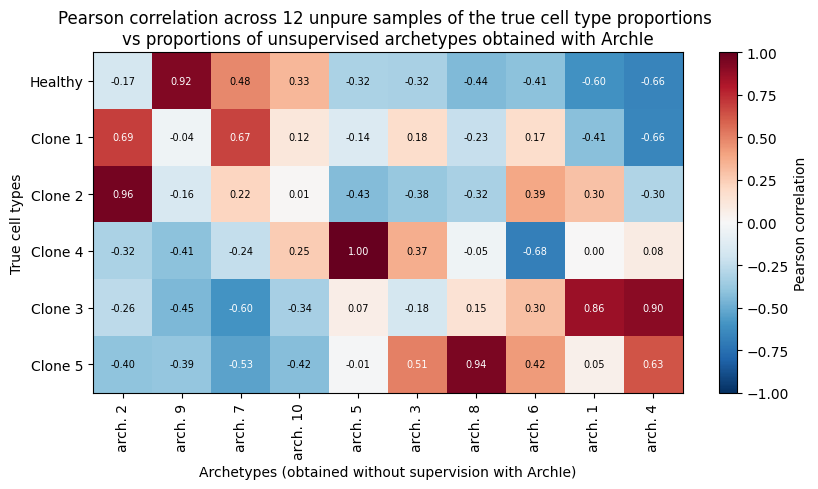

In [154]:
# Pairwise Pearson correlation (across samples) between the true per-sample
# source proportions (exp3_prop_per_sample, columns = EXP3_SOURCES) and the
# archetype estimated proportions (exp3_est_props, columns = archetypes).
# Rows (sources) and columns (archetypes) are hierarchically clustered on this
# correlation matrix; the resulting source_order / arch_order are reused by the
# two P(archetype | read) heatmaps below.
n_sources = len(EXP3_SOURCES)
corr_matrix = np.zeros((n_sources, EXP3_N_ARCHETYPES))
for s in range(n_sources):
    for a in range(EXP3_N_ARCHETYPES):
        corr_matrix[s, a] = np.corrcoef(
            exp3_prop_per_sample[:, s], exp3_est_props[:, a]
        )[0, 1]

if n_sources > 1:
    source_order = dendrogram(
        linkage(corr_matrix, method="average", metric="correlation"), no_plot=True
    )["leaves"]
else:
    source_order = list(range(n_sources))
if EXP3_N_ARCHETYPES > 1:
    arch_order = dendrogram(
        linkage(corr_matrix.T, method="average", metric="correlation"), no_plot=True
    )["leaves"]
else:
    arch_order = list(range(EXP3_N_ARCHETYPES))

corr_ordered = corr_matrix[source_order][:, arch_order]

fig, ax = plt.subplots(
    figsize=(0.55 * EXP3_N_ARCHETYPES + 3, 0.5 * n_sources + 2)
)
im = ax.imshow(corr_ordered, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(EXP3_N_ARCHETYPES))
ax.set_xticklabels([f"arch. {a + 1}" for a in arch_order], rotation=90)
ax.set_yticks(range(n_sources))
ax.set_yticklabels([ctype_plot_name[EXP3_SOURCES[s]] for s in source_order])
ax.set_xlabel("Archetypes (obtained without supervision with ArchIe)")
ax.set_ylabel("True cell types")
ax.set_title(
    f"Pearson correlation across {EXP3_N_SAMPLES} unpure samples of the true cell type proportions \n"
    "vs proportions of unsupervised archetypes obtained with ArchIe"
)
for i in range(n_sources):
    for j in range(EXP3_N_ARCHETYPES):
        ax.text(
            j, i, f"{corr_ordered[i, j]:.2f}",
            ha="center", va="center", fontsize=7,
            color="white" if abs(corr_ordered[i, j]) > 0.5 else "black",
        )
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR
    / f"grant_graphs_corr_true_vs_estimated_proportions_narchetypes={EXP3_N_ARCHETYPES}_penalty={EXP3_PENALTY}_alpha={EXP3_DIRICHLET_ALPHA}_nreadspersample={EXP3_SAMPLE_SIZE}_nregions={EXP3_N_SAMPLES}.pdf",
    bbox_inches="tight"
)
plt.show()

### Average P(archetype | read) per source



We first apply a **confidence filter**: for every `(region, start, read_length,
signature)` we compute $P(\mathrm{archetype}\mid\mathrm{signature})$ and keep only
the positions whose top-1 vs top-2 archetype posterior gap exceeds
`EXP3_MIN_POSTERIOR_GAP`. Then, for every source (the healthy cell type and each
tumor clone) we score its reads matching a kept signature with the fitted
archetypes and average the posterior $P(\mathrm{archetype}\mid\mathrm{read})$
(uniform prior over the archetypes), weighting each read by its multiplicity. The
heatmap includes the healthy cell type as an extra row.

In [170]:
# Confidence filter (replaces the deprecated EXP3_MIN_LENGTH_FOR_HEATMAP length
# filter). For every (region, start, read_length, signature) we compute
# P(archetype | signature) and keep the position only if the gap between the
# largest and the second-largest archetype posterior exceeds
# EXP3_MIN_POSTERIOR_GAP. Only reads matching a kept signature will contribute to
# the heatmap below.
EXP3_MIN_POSTERIOR_GAP = 0.3
ONLY_UNSPECIFIC_REGIONS = False  # True -> keep only unspecific regions for the heatmap (and disregard the posterior gap filter)
GAP_TYPE= "top1-vs-worst"
allowed_signatures = defaultdict(set)  # (region_id, start, read_length) -> {pattern}
n_allowed, n_total_sig = 0, 0
for region in exp3_selected_regions:
    region_id = region["region_id"]
    region_setting = region["setting"]
    if ONLY_UNSPECIFIC_REGIONS and region_setting != "unspecific":
        continue
    for start, read_lengths in signature_positions[region_id].items():
        for read_length in read_lengths:
            for sig_idx in range(2**read_length):
                pattern = "".join(
                    str(int(b)) for b in get_sig_from_idx(sig_idx, read_length)
                )
                post = posterior_ctype_given_read(
                    exp3_archetypes_info, region_id, start, pattern
                )
                if post is None:  # signature outside the archetype span
                    continue
                n_total_sig += 1
                if ONLY_UNSPECIFIC_REGIONS:
                    allowed_signatures[(region_id, start, read_length)].add(pattern)
                    n_allowed += 1
                elif GAP_TYPE == "top1-vs-top2":
                    top2 = np.sort(post)[::-1][:2]
                    if top2[0] - top2[1] > EXP3_MIN_POSTERIOR_GAP:
                        allowed_signatures[(region_id, start, read_length)].add(pattern)
                        n_allowed += 1
                elif GAP_TYPE == "top1-vs-worst":
                    top1 = np.max(post)
                    worst = np.min(post)
                    if top1 - worst > EXP3_MIN_POSTERIOR_GAP:
                        allowed_signatures[(region_id, start, read_length)].add(pattern)
                        n_allowed += 1

print(
    f"Kept {n_allowed}/{n_total_sig} confident (region, start, length, signature) positions"
)
if ONLY_UNSPECIFIC_REGIONS:
    print(f"Kept only unspecific regions for the heatmap (disregarding posterior gap).")
else:
    print(
        f"Kept only positions with gap > {EXP3_MIN_POSTERIOR_GAP} with gap_type={GAP_TYPE}."
    )

Kept 31210/32832 confident (region, start, length, signature) positions
Kept only positions with gap > 0.3 with gap_type=top1-vs-worst.


In [171]:
# Average P(archetype | read) per source, over reads whose signature passed the
# confidence filter (allowed_signatures). We also count, per source, the number of
# reads hard-assigned to each archetype (argmax of the posterior).
sum_posterior_per_source = np.zeros((len(EXP3_SOURCES), EXP3_N_ARCHETYPES))
n_reads_per_source = np.zeros(len(EXP3_SOURCES))
read_count_per_source_arch = np.zeros((len(EXP3_SOURCES), EXP3_N_ARCHETYPES))

for region in exp3_selected_regions:
    region_id = region["region_id"]
    for source_idx, source in enumerate(EXP3_SOURCES):
        source_ds = exp3_dataset[region_id].get(source, {})
        for read_length, start_dict in source_ds.items():
            for start, pattern_counts in start_dict.items():
                allowed = allowed_signatures.get((region_id, start, read_length))
                if not allowed:
                    continue
                for pattern, n_reads in pattern_counts.items():
                    if pattern not in allowed:
                        continue
                    post = posterior_ctype_given_read(
                        exp3_archetypes_info, region_id, start, pattern
                    )
                    if post is None:  # read outside the archetype span
                        continue
                    sum_posterior_per_source[source_idx] += n_reads * post
                    n_reads_per_source[source_idx] += n_reads
                    read_count_per_source_arch[source_idx, np.argmax(post)] += n_reads

mean_posterior_per_source = np.divide(
    sum_posterior_per_source,
    np.clip(n_reads_per_source[:, None], EPS, None),
)
print("Reads used per source (confident signatures only):")
for source, n in zip(EXP3_SOURCES, n_reads_per_source):
    print(f"  {source}: {int(n)}")

Reads used per source (confident signatures only):
  Liver-Hep: 4103
  Pancreas-Alpha: 2230
  Pancreas-Beta: 1829
  Pancreas-Delta: 2051
  Pancreas-Acinar: 3657
  Pancreas-Duct: 2369


Mean P(archetype | read) heatmap (confident signatures, gap > 0.3)
gap type: top1-vs-worst, penalty_strength=0.0


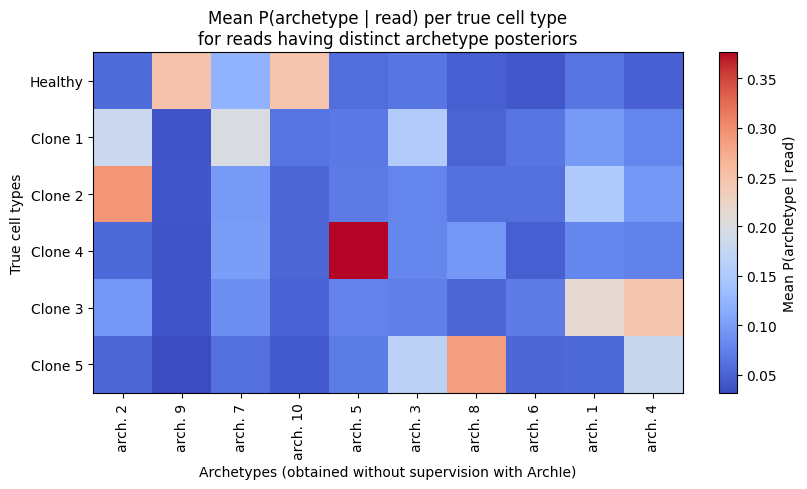

In [172]:
# Mean P(archetype | read) per source. Rows (sources) and columns (archetypes)
# reuse the hierarchical-clustering order computed on the correlation heatmap
# above (source_order, arch_order).
heatmap_matrix = mean_posterior_per_source[source_order][:, arch_order]

fig, ax = plt.subplots(
    figsize=(0.55 * EXP3_N_ARCHETYPES + 3, 0.5 * len(EXP3_SOURCES) + 2)
)
im = ax.imshow(
    heatmap_matrix, aspect="auto", cmap="coolwarm", vmin=np.min(heatmap_matrix), vmax=np.max(heatmap_matrix)
)
ax.set_xticks(range(EXP3_N_ARCHETYPES))
ax.set_xticklabels([f"arch. {a + 1}" for a in arch_order], rotation=90)
ax.set_yticks(range(len(EXP3_SOURCES)))
ax.set_yticklabels([ctype_plot_name[EXP3_SOURCES[s]] for s in source_order])
ax.set_xlabel("Archetypes (obtained without supervision with ArchIe)")
ax.set_ylabel("True cell types")
print(
    f"Mean P(archetype | read) heatmap (confident signatures, gap > {EXP3_MIN_POSTERIOR_GAP})\n"
    f"gap type: {GAP_TYPE}, penalty_strength={EXP3_PENALTY}"
)
ax.set_title(
    "Mean P(archetype | read) per true cell type\n"
    "for reads having distinct archetype posteriors"
)
fig.colorbar(im, ax=ax, label="Mean P(archetype | read)")
plt.tight_layout()
# plt.savefig(
#     OUTPUT_DIR
#     / f"grant_graphs_mean_posterior_per_source_penalty={EXP3_PENALTY}_alpha={EXP3_DIRICHLET_ALPHA}_nreadspersample={EXP3_SAMPLE_SIZE}_nregions={EXP3_N_SAMPLES}_gap={GAP_TYPE}_minposterior={EXP3_MIN_POSTERIOR_GAP}.pdf",
#     bbox_inches="tight",
# )
plt.show()

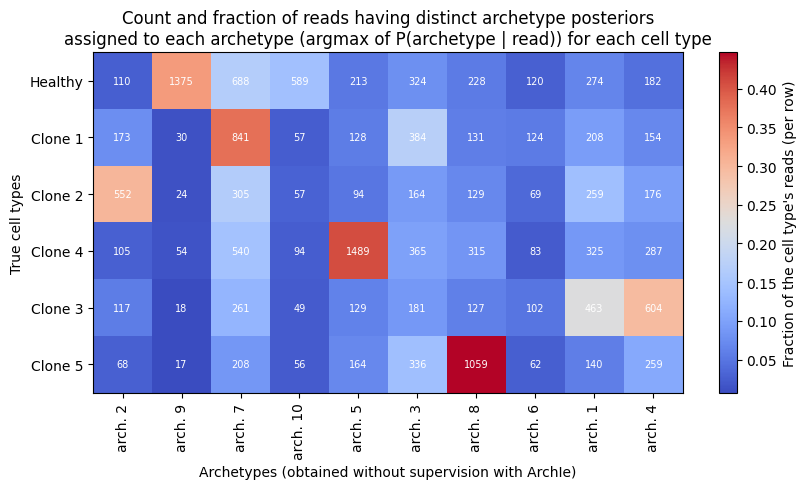

In [173]:
# Heatmap of the number of confident reads hard-assigned to each archetype
# (archetype = argmax of the read's posterior), per source. Cell text is the raw
# read count; the color is the count normalized per row (per source/ctype). Rows
# and columns reuse the correlation-heatmap clustering order (source_order,
# arch_order).
row_sums = np.clip(read_count_per_source_arch.sum(axis=1, keepdims=True), EPS, None)
norm_counts = read_count_per_source_arch / row_sums
counts_ordered = read_count_per_source_arch[source_order][:, arch_order]
norm_ordered = norm_counts[source_order][:, arch_order]

fig, ax = plt.subplots(
    figsize=(0.55 * EXP3_N_ARCHETYPES + 3, 0.5 * len(EXP3_SOURCES) + 2)
)
im = ax.imshow(norm_ordered, aspect="auto", cmap="coolwarm", vmin=norm_ordered.min(), vmax=norm_ordered.max())
ax.set_xticks(range(EXP3_N_ARCHETYPES))
ax.set_xticklabels([f"arch. {a + 1}" for a in arch_order], rotation=90)
ax.set_yticks(range(len(EXP3_SOURCES)))
ax.set_yticklabels([ctype_plot_name[EXP3_SOURCES[s]] for s in source_order])
ax.set_xlabel("Archetypes (obtained without supervision with ArchIe)")
ax.set_ylabel("True cell types")
ax.set_title(
    "Count and fraction of reads having distinct archetype posteriors\n"
    "assigned to each archetype (argmax of P(archetype | read)) for each cell type"
)

# Annotate each cell with the raw read count.
for i in range(len(EXP3_SOURCES)):
    for j in range(EXP3_N_ARCHETYPES):
        ax.text(
            j,
            i,
            f"{int(counts_ordered[i, j])}",
            ha="center",
            va="center",
            fontsize=7,
            color="white" if norm_ordered[i, j] < 0.5 else "black",
        )

fig.colorbar(im, ax=ax, label="Fraction of the cell type's reads (per row)")
plt.tight_layout()
# plt.savefig(
#     OUTPUT_DIR
#     / f"grant_graphs_count_and_fraction_per_source_per_archetype_penalty={EXP3_PENALTY}_alpha={EXP3_DIRICHLET_ALPHA}_nreadspersample={EXP3_SAMPLE_SIZE}_nregions={EXP3_N_SAMPLES}_gap={GAP_TYPE}_minposterior={EXP3_MIN_POSTERIOR_GAP}.pdf",
#     bbox_inches="tight",
# )
plt.show()

### Archetype methylation profiles

Methylation value P(methylated) of each fitted archetype at every CpG position, shown as one small heatmap per region (regions kept clearly separated). Archetype rows reuse the `arch_order` clustering from the correlation heatmap.


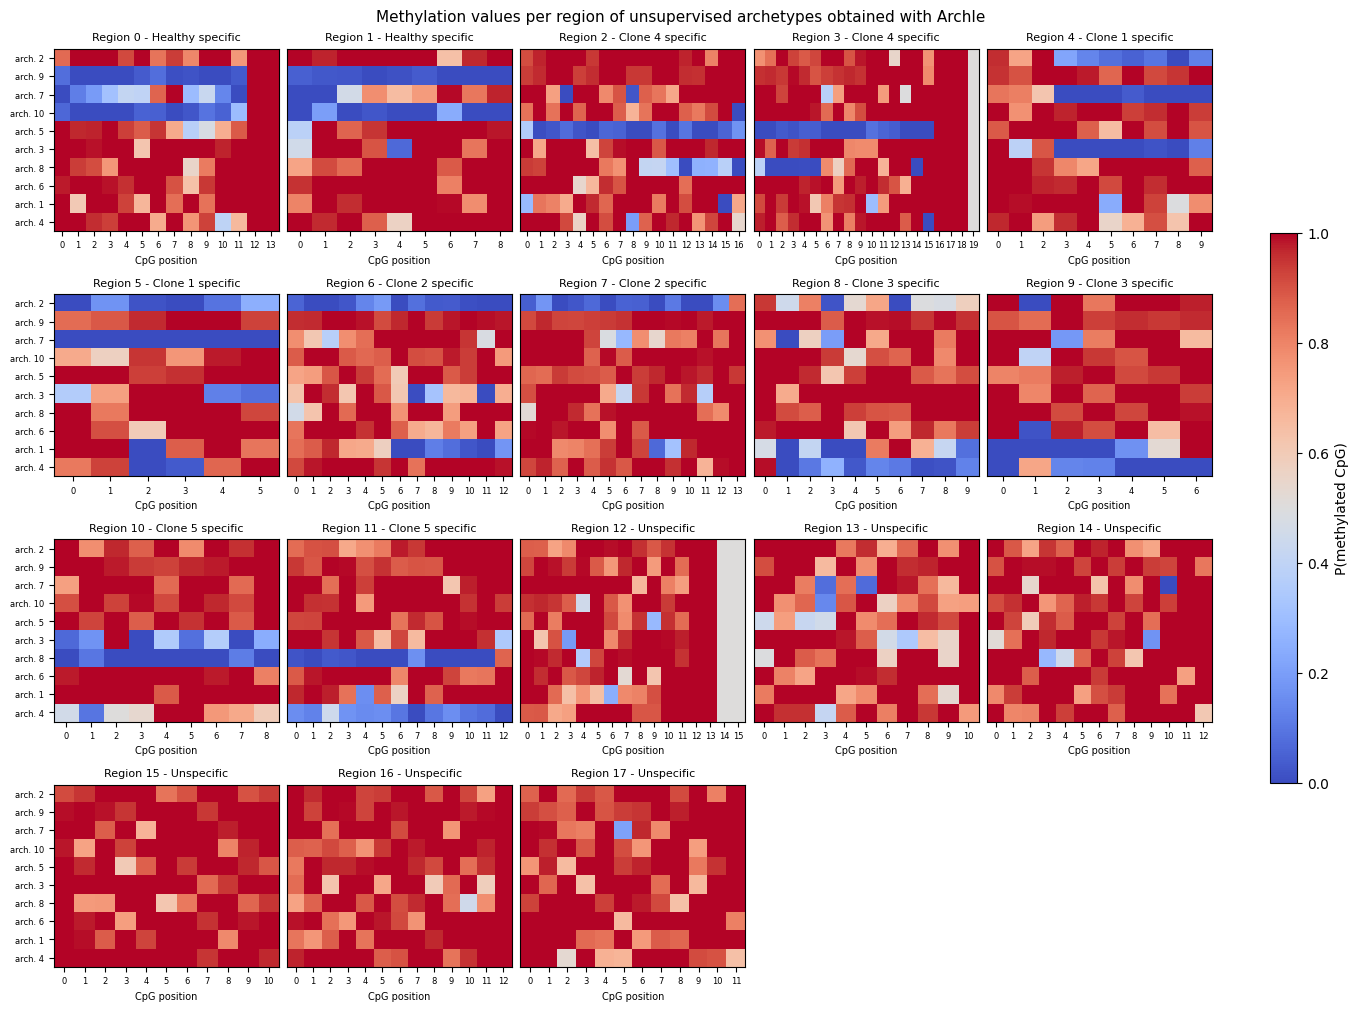

In [174]:
# Heatmap of the fitted archetype methylation values (P(methylated) per CpG).
# One small sub-heatmap per region so the regions stay clearly separated; the
# subplots are laid out on a near-square grid so the overall figure is neither
# too wide nor too tall. Archetype rows reuse arch_order for consistency.

archetypes_by_region = exp3_archetypes_info["archetypes"]
region_ids = [r["region_id"] for r in exp3_selected_regions if r["region_id"] in archetypes_by_region]

n_reg = len(region_ids)
ncols = math.ceil(math.sqrt(n_reg))
nrows = math.ceil(n_reg / ncols)

fig, axes = plt.subplots(
    nrows, ncols, figsize=(2.7 * ncols, 2.5 * nrows), squeeze=False,
    layout="constrained",
)
region_setting = {r["region_id"]: r for r in exp3_selected_regions}
arch_labels = [f"arch. {a + 1}" for a in arch_order]

im = None
for k, region_id in enumerate(region_ids):
    ax = axes[k // ncols][k % ncols]
    meth = archetypes_by_region[region_id][arch_order]  # (n_archetypes, n_CpG)
    im = ax.imshow(meth, aspect="auto", cmap="coolwarm", vmin=0, vmax=1)
    info = region_setting[region_id]
    title = f"Region {region_id}"
    if info["setting"] =="unspecific":
        title += " - Unspecific"
    else:
        title += f" - {ctype_plot_name[info['target']]} specific"
    ax.set_title(title, fontsize=8)
    ax.set_xlabel("CpG position", fontsize=7)
    ax.set_xticks(range(meth.shape[1]))
    ax.tick_params(labelsize=6)
    if k % ncols == 0:
        ax.set_yticks(range(len(arch_order)))
        ax.set_yticklabels(arch_labels, fontsize=6)
    else:
        ax.set_yticks([])

# Hide any unused axes on the grid.
for k in range(n_reg, nrows * ncols):
    axes[k // ncols][k % ncols].axis("off")

fig.set_constrained_layout_pads(hspace=0.05, wspace=0.02)
fig.suptitle("Methylation values per region of unsupervised archetypes obtained with ArchIe", fontsize=11)
fig.colorbar(
    im, ax=axes.ravel().tolist(), shrink=0.6, label="P(methylated CpG)"
)
plt.savefig(
    OUTPUT_DIR
    / f"grant_graphs_archetype_methylation_values_per_region_penalty={EXP3_PENALTY}_alpha={EXP3_DIRICHLET_ALPHA}_nreadspersample={EXP3_SAMPLE_SIZE}_nregions={EXP3_N_SAMPLES}_gap={GAP_TYPE}_minposterior={EXP3_MIN_POSTERIOR_GAP}.pdf",
    bbox_inches="tight",
)
plt.show()

### Evolution of the archetypes across EM iterations

We re-fit Experiment 3 with `record_history=True` to snapshot the archetypes at every EM iteration (frame 0 = initialization), then animate the per-region methylation grid across iterations (inline slider + saved GIF) and show the convergence curve and per-archetype distance-to-final trajectories.


In [176]:
# Re-fit exp3 capturing the archetypes at every EM iteration. Same inputs and
# seed as the original fit, so it reproduces exp3_est_props / exp3_archetypes_info
# exactly; the extra return value exp3_history holds the per-iteration snapshots.
(
    _exp3_p_sig_hist,
    _exp3_est_props_hist,
    _exp3_archetypes_info_hist,
    exp3_history,
) = sl_with_simple_archetypes_with_multiple_regions(
    exp3_counts_sig_per_sample,
    exp3_init_props,
    reestimate_ctype_proba_per_sample=True,
    max_num_iterations=EXP3_MAX_NUM_ITERATIONS,
    delta_tol=EXP3_DELTA_TOL,
    return_archetypes=True,
    record_history=True,
    penalty_strength=EXP3_PENALTY,
    verbose=True,
)
print(f"Captured {len(exp3_history)} frames (iterations 0..{exp3_history[-1]['iteration']}).")

Reached max_num_iterations=500 with delta=5.13e-03.
Captured 501 frames (iterations 0..500).


Saved output/clone_archetypes/exp3_archetype_evolution_narch=10.gif


Animation size has reached 21041897 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


KeyboardInterrupt: 

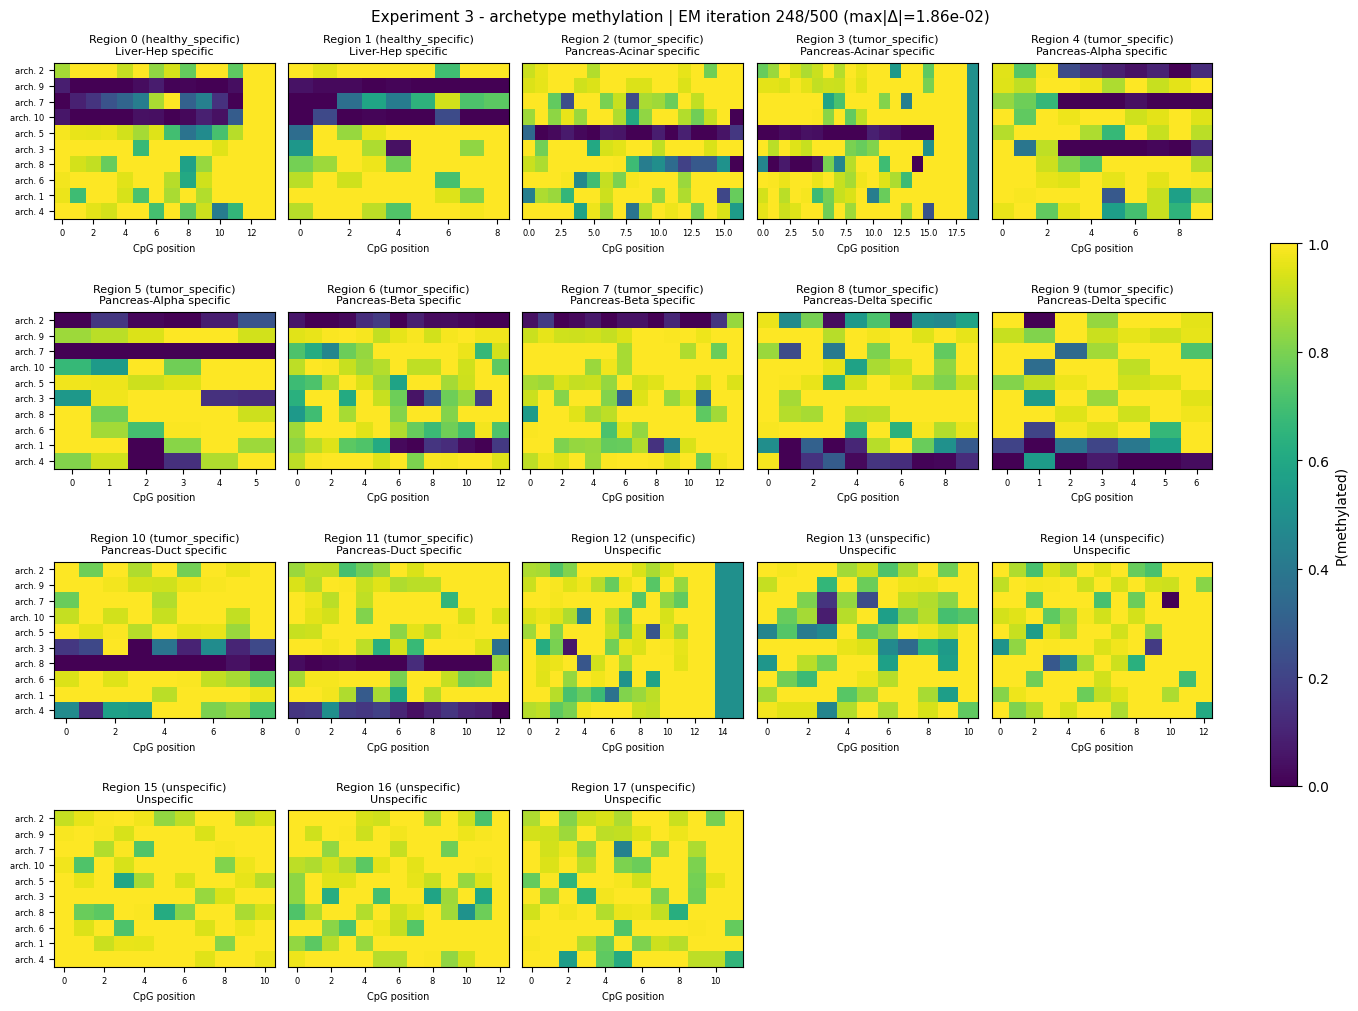

In [ ]:
# Animate the per-region archetype methylation grid across EM iterations.
# The grid layout matches the static heatmap above (near-square, regions clearly
# separated, arch_order rows). We display an inline player with a scrub slider
# (to_jshtml) and also save a shareable GIF.
from matplotlib import animation


def build_archetype_grid(archetypes_by_region, regions, arch_order):
    """Build the per-region methylation grid; return (fig, {region_id: im}, ids)."""
    region_ids = [
        r["region_id"] for r in regions if r["region_id"] in archetypes_by_region
    ]
    n_reg = len(region_ids)
    ncols = math.ceil(math.sqrt(n_reg))
    nrows = math.ceil(n_reg / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(2.7 * ncols, 2.5 * nrows), squeeze=False,
        layout="constrained",
    )
    region_setting = {r["region_id"]: r for r in regions}
    arch_labels = [f"arch. {a + 1}" for a in arch_order]
    ims = {}
    for k, region_id in enumerate(region_ids):
        ax = axes[k // ncols][k % ncols]
        meth = archetypes_by_region[region_id][arch_order]
        ims[region_id] = ax.imshow(meth, aspect="auto", cmap="coolwarm", vmin=0, vmax=1)
        info = region_setting[region_id]
        title = f"Region {region_id} ({info['setting']})"
        title += "\nUnspecific" if info["setting"] == "unspecific" else f"\n{info['target']} specific"
        ax.set_title(title, fontsize=8)
        ax.set_xlabel("CpG position", fontsize=7)
        ax.tick_params(labelsize=6)
        if k % ncols == 0:
            ax.set_yticks(range(len(arch_order)))
            ax.set_yticklabels(arch_labels, fontsize=6)
        else:
            ax.set_yticks([])
    for k in range(n_reg, nrows * ncols):
        axes[k // ncols][k % ncols].axis("off")
    fig.set_constrained_layout_pads(hspace=0.12, wspace=0.05)
    fig.colorbar(ims[region_ids[0]], ax=axes.ravel().tolist(), shrink=0.6, label="P(methylated)")
    return fig, ims, region_ids


fig, ims, region_ids = build_archetype_grid(
    exp3_history[0]["archetypes"], exp3_selected_regions, arch_order
)
suptitle = fig.suptitle("", fontsize=11)
last_iter = exp3_history[-1]["iteration"]


def _update(frame):
    snap = exp3_history[frame]
    for region_id in region_ids:
        ims[region_id].set_data(snap["archetypes"][region_id][arch_order])
    delta = snap["delta"]
    delta_str = "initialization" if not np.isfinite(delta) else f"max|\u0394|={delta:.2e}"
    suptitle.set_text(
        f"Experiment 3 - archetype methylation | EM iteration "
        f"{snap['iteration']}/{last_iter} ({delta_str})"
    )
    return list(ims.values()) + [suptitle]


anim = animation.FuncAnimation(
    fig, _update, frames=len(exp3_history), interval=350, blit=False
)
gif_path = OUTPUT_DIR / f"exp3_archetype_evolution_narch={EXP3_N_ARCHETYPES}.gif"
anim.save(gif_path, writer=animation.PillowWriter(fps=3))
print(f"Saved {gif_path}")

plt.close(fig)  # prevent a duplicate static figure from being displayed

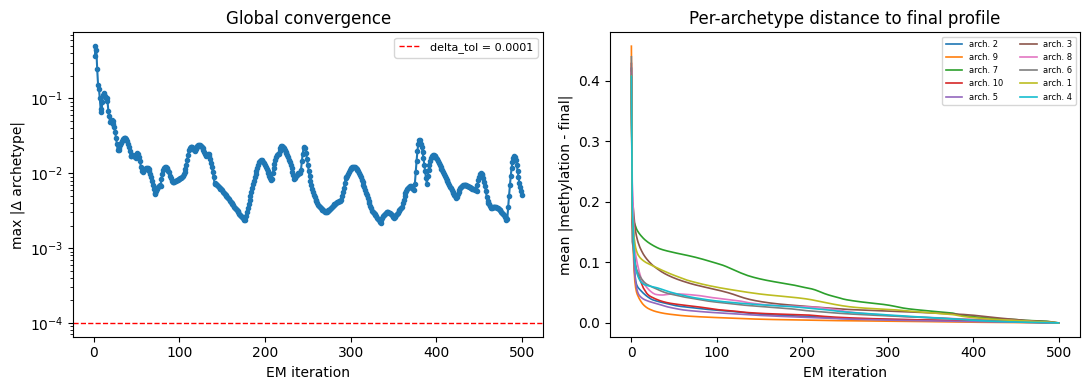

In [178]:
# Quantitative companion to the animation: (left) global convergence, the max
# absolute archetype change per iteration on a log scale; (right) per-archetype
# distance to the final methylation profile (mean |mu_t - mu_final| over all
# regions and CpGs), showing which archetypes stabilize early vs late.
final = exp3_history[-1]["archetypes"]
hist_region_ids = list(final.keys())
all_iters = [s["iteration"] for s in exp3_history]

traj = np.zeros((len(exp3_history), EXP3_N_ARCHETYPES))
for t, snap in enumerate(exp3_history):
    for a in range(EXP3_N_ARCHETYPES):
        diffs = np.concatenate(
            [np.abs(snap["archetypes"][r][a] - final[r][a]) for r in hist_region_ids]
        )
        traj[t, a] = diffs.mean()

# Convergence: delta per iteration (skip frame 0 whose delta is inf by convention).
conv_iters = [s["iteration"] for s in exp3_history[1:]]
conv_deltas = [s["delta"] for s in exp3_history[1:]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.semilogy(conv_iters, conv_deltas, marker="o", ms=3)
ax1.axhline(EXP3_DELTA_TOL, color="red", ls="--", lw=1, label=f"delta_tol = {EXP3_DELTA_TOL:g}")
ax1.set_xlabel("EM iteration")
ax1.set_ylabel("max |\u0394 archetype|")
ax1.set_title("Global convergence")
ax1.legend(fontsize=8)

cmap = plt.get_cmap("tab20" if EXP3_N_ARCHETYPES > 10 else "tab10")
for i, a in enumerate(arch_order):
    ax2.plot(all_iters, traj[:, a], label=f"arch. {a + 1}", lw=1.2, color=cmap(i % cmap.N))
ax2.set_xlabel("EM iteration")
ax2.set_ylabel("mean |methylation - final|")
ax2.set_title("Per-archetype distance to final profile")
ax2.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.show()